# Importing Libraries

In [166]:
import kagglehub
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Data

## Loading Datasets
This project uses 3 main datasets
- results: CSV file containing information on international football matches from 1872 to 2026.
- wc2026_draw: CSV file containing the countries that have qualified for the World Cup 2026 and their groupings.
- players: CSV file containing basic information (age, nationality etc.) and ratings (overall and categorical) of players based on EA Sports FIFA 25.

Additional datasets: goalscorers, shootouts and former names. These datasets are not used for this project.

In [167]:
# Loading Datasets
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
path2 = kagglehub.dataset_download("rovnez/fc-26-fifa-26-player-data")

# 1. List available files
dataset_path = Path(path)
files = list(dataset_path.glob("*"))
print("Available files:", [f.name for f in files])

# 2. Read CSV files
goalscorers = pd.read_csv(dataset_path / "goalscorers.csv")
shootouts = pd.read_csv(dataset_path / "shootouts.csv")
results = pd.read_csv(dataset_path / "results.csv")
former_names = pd.read_csv(dataset_path / "former_names.csv")
wc2026_draw = pd.read_csv("../data/wc2026_draw.csv")
players = pd.read_csv(Path(path2) / "FC26_20250921.csv")
elo_ratings = pd.read_csv("../data/fifa_ranking-2026-04-01.csv") # the file's points and rank column match those of World Football Elo Ratings, in spite of its name as a fifa ranking csv

# 3. Verification
results.info()
print(results.tail())
print(wc2026_draw.head())
print(former_names.head())
players.info()
elo_ratings.info()

Available files: ['goalscorers.csv', 'shootouts.csv', 'results.csv', 'former_names.csv']
<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB
             date home_team   away_team  home_score  away_score  \
49282  2026-06-27    Jordan   Argentina         NaN         NaN   
49283  2026-06-27  Colombia    Portugal         NaN         NaN   
49284  2026-06-27  DR Congo  Uzbekistan         NaN         NaN   
49285  2026-06-27    Panama     Englan

/var/folders/h7/yghyn5k95wb5h2ph99hrr0680000gn/T/ipykernel_30454/3700083093.py:16: DtypeWarning: Columns (0: player_tags) have mixed types. Specify dtype option on import or set low_memory=False.
  players = pd.read_csv(Path(path2) / "FC26_20250921.csv")


In [168]:
players["fifa_update"].nunique()

1

## Data Cleaning

Basic cleanup.

In [169]:
# Removing duplicates
results.drop_duplicates(inplace=True)
wc2026_draw.drop_duplicates(inplace=True)
players.drop_duplicates(inplace=True)
elo_ratings.drop_duplicates(inplace=True)

# Converting date column from string to datetime format
results["date"] = pd.to_datetime(results["date"], errors="coerce")
results.info()
elo_ratings["rank_date"] = pd.to_datetime(elo_ratings["rank_date"], errors="coerce")
elo_ratings.info()

# Retain only important columns from the players dataset
players = players[["player_id", "short_name", "overall", "player_positions", "nationality_name"]]

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49287 non-null  datetime64[us]
 1   home_team   49287 non-null  str           
 2   away_team   49287 non-null  str           
 3   home_score  49215 non-null  float64       
 4   away_score  49215 non-null  float64       
 5   tournament  49287 non-null  str           
 6   city        49287 non-null  str           
 7   country     49287 non-null  str           
 8   neutral     49287 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(5)
memory usage: 3.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 70194 entries, 0 to 70193
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       70194 non-null  int64         
 1   rank             70185 non-null  float

Saving World Cup 2026 group stage match fixtures for future use.

In [170]:
wc2026_matches = results[(results["date"] >= "2026-06-11") & (results["tournament"] == "FIFA World Cup")]
wc2026_matches

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49215,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49216,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49217,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49218,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49219,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [171]:
wc2026_matches.to_csv("../data/processed/wc2026_matches.csv", index=False)

results df includes future matches that have not taken place and therefore have NA values. 

In [172]:
# Removing rows that have NA values in critical columns
results = results.dropna(subset=["home_team", "away_team", "home_score", "away_score"])
print(results.tail())

# Latest international match is on 2026-03-31

            date       home_team away_team  home_score  away_score  \
49210 2026-03-31          Kosovo    Turkey         0.0         1.0   
49211 2026-03-31  Czech Republic   Denmark         2.0         2.0   
49212 2026-03-31        Cameroon  China PR         2.0         0.0   
49213 2026-03-31       Australia   Curaçao         5.0         1.0   
49214 2026-03-31      Kazakhstan   Comoros         1.0         0.0   

                         tournament       city         country  neutral  
49210  FIFA World Cup qualification   Pristina          Kosovo    False  
49211  FIFA World Cup qualification     Prague  Czech Republic    False  
49212                   FIFA Series  Melbourne       Australia     True  
49213                   FIFA Series  Melbourne       Australia    False  
49214                   FIFA Series     Astana      Kazakhstan    False  


In [173]:
# Converting home_score and away_score to integers
results["home_score"] = results["home_score"].astype(int)
results["away_score"] = results["away_score"].astype(int)
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 49215 entries, 0 to 49214
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49215 non-null  datetime64[us]
 1   home_team   49215 non-null  str           
 2   away_team   49215 non-null  str           
 3   home_score  49215 non-null  int64         
 4   away_score  49215 non-null  int64         
 5   tournament  49215 non-null  str           
 6   city        49215 non-null  str           
 7   country     49215 non-null  str           
 8   neutral     49215 non-null  bool          
dtypes: bool(1), datetime64[us](1), int64(2), str(5)
memory usage: 3.1 MB


In [174]:
# Fixing former country names in results dataset
former_names_mapping = dict(zip(former_names["former"], former_names["current"]))
results["home_team"] = results["home_team"].replace(former_names_mapping)
results["away_team"] = results["away_team"].replace(former_names_mapping)

In [175]:
# Filtering for the latest elo ratings
latest_rank_date = elo_ratings["rank_date"].max()
elo_ratings = elo_ratings[elo_ratings["rank_date"] == latest_rank_date]
print(elo_ratings.head())

       Unnamed: 0  rank country_full country_abrv  total_points  \
69992       69992   1.0        Spain          ESP        2165.0   
69993       69993   2.0    Argentina          ARG        2113.0   
69994       69994   3.0       France          FRA        2082.0   
69995       69995   4.0      England          ENG        2020.0   
69996       69996   5.0       Brazil          BRA        1984.0   

       previous_points  rank_change confederation  rank_date  
69992          1877.18            0          UEFA 2026-04-01  
69993          1873.33            0      CONMEBOL 2026-04-01  
69994          1870.00            0          UEFA 2026-04-01  
69995          1834.12            0          UEFA 2026-04-01  
69996          1760.46            0      CONMEBOL 2026-04-01  


In [176]:
# Rename nationality column of players dataset
players.rename(columns={"nationality_name": "nationality"}, inplace=True)

# Checking the names of nationalities in the players dataset
with pd.option_context('display.max_seq_items', None):
    print(players["nationality"].unique())

<StringArray>
[                 'England',                  'Uruguay',
                  'Germany',                  'Morocco',
                    'Italy',                  'Türkiye',
                'Argentina',                    'Spain',
                   'France',                 'Portugal',
                    'Egypt',                  'Austria',
              'Netherlands',                  'Hungary',
                   'Brazil',                   'Serbia',
                  'Armenia',                  'Belgium',
                  'Georgia',                  'Algeria',
                   'Norway',                 'Scotland',
                   'Poland',                  'Croatia',
                 'Cameroon',                    'Gabon',
            'Côte d'Ivoire',                   'Sweden',
            'United States',                   'Canada',
                  'Ecuador',                  'Denmark',
                    'Japan',                 'Colombia',
                '

In [177]:
# Checking the names of countries in the elo ratings dataset
with pd.option_context('display.max_seq_items', None):
    print(elo_ratings["country_full"].unique())

<StringArray>
[                   'Spain',                'Argentina',
                   'France',                  'England',
                   'Brazil',                 'Portugal',
                 'Colombia',              'Netherlands',
                  'Ecuador',                  'Croatia',
                  'Germany',                   'Norway',
                    'Japan',                  'Türkiye',
                  'Uruguay',              'Switzerland',
                  'Senegal',                  'Denmark',
                  'Belgium',                   'Mexico',
                    'Italy',                 'Paraguay',
                  'Austria',                  'Morocco',
                   'Canada',                'Australia',
                   'Russia',                   'Serbia',
                 'Scotland',                  'Ukraine',
                  'IR Iran',           'Korea Republic',
                  'Nigeria',                   'Greece',
                 

Names of countries are not consistent across datasets.

In [ ]:
# Create a list of countries that are participating in the World Cup 2026
countries_in_wc2026 = wc2026_draw["country"].tolist()
print(countries_in_wc2026)

# Country mapping to fix inconsistencies in country names between datasets, focusing on the countries that are participating in the World Cup 2026
country_mapping = {
    "Holland": "Netherlands",
    "Côte d'Ivoire": "Ivory Coast",
    "USA": "United States",
    "Korea Republic": "South Korea",
    "Cape Verde Islands": "Cape Verde",
    "Congo DR": "DR Congo",
    "Czechia": "Czech Republic",
    "Türkiye": "Turkey",
    "IR Iran": "Iran",
    "Cabo Verde": "Cape Verde",
    "Curacao": "Curaçao"
}
# Apply country mapping to the players and elo_ratings dataset
players["nationality"] = players["nationality"].replace(country_mapping)
elo_ratings["country_full"] = elo_ratings["country_full"].replace(country_mapping)

# Check for countries that failed to map
player_nationalities = players["nationality"].unique().tolist()
for i in countries_in_wc2026:
    if i not in player_nationalities:
        print(f"Country missing from players dataset: {i}") # No missing countries from the players dataset & all differing country names have been included in the mapping dictionary
for i in countries_in_wc2026:
    if i not in elo_ratings["country_full"].unique().tolist():
        print(f"Country missing from elo ratings dataset: {i}") # No missing countries from the elo ratings dataset & all differing country names have been included in the mapping dictionary

# Keep only players from countries that are participating in the World Cup 2026
wcplayers = players[players["nationality"].isin(countries_in_wc2026)]
# Keep only countries that are participating in the World Cup 2026 in elo ratings dataset
wc2026_elo = elo_ratings[elo_ratings["country_full"].isin(countries_in_wc2026)]

['Mexico', 'South Africa', 'South Korea', 'Czech Republic', 'Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland', 'Brazil', 'Morocco', 'Haiti', 'Scotland', 'United States', 'Paraguay', 'Australia', 'Turkey', 'Germany', 'Curaçao', 'Ivory Coast', 'Ecuador', 'Netherlands', 'Japan', 'Sweden', 'Tunisia', 'Belgium', 'Egypt', 'Iran', 'New Zealand', 'Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay', 'France', 'Senegal', 'Iraq', 'Norway', 'Argentina', 'Algeria', 'Austria', 'Jordan', 'Portugal', 'DR Congo', 'Uzbekistan', 'Colombia', 'England', 'Croatia', 'Ghana', 'Panama']


In [179]:
# Standardising country names in the results dataset
results["home_team"] = results["home_team"].replace(country_mapping)
results["away_team"] = results["away_team"].replace(country_mapping)
results["country"] = results["country"].replace(country_mapping)

## Exploratory Data Analysis and Visualisation

### Home Ground Advantage
#### Comparison of Match Outcomes Across All International Matches in Home and Neutral Ground
A column chart of the win, draw and loss rates for international football teams in home ground vs neutral ground to explore the home turf advantage.

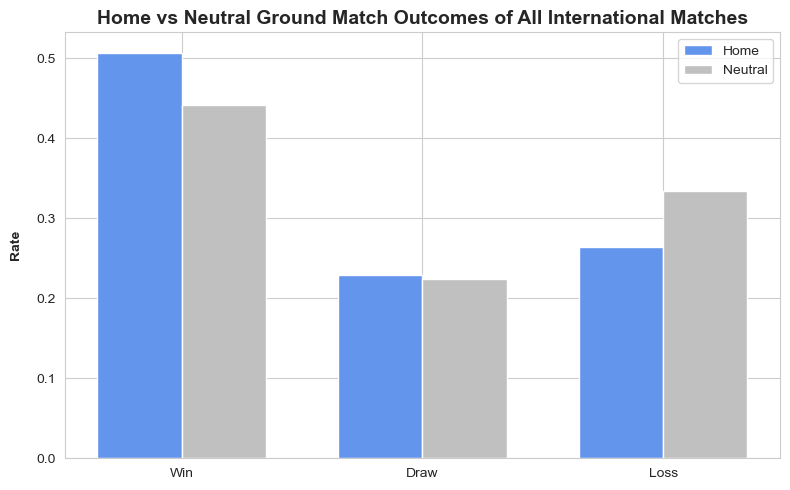

In [180]:
# Fix the result column creation
conditions = [
    results["home_score"] > results["away_score"],
    results["home_score"] == results["away_score"],
    results["home_score"] < results["away_score"]
]
choices = [1, 0, -1]
results["home_result"] = np.select(conditions, choices)
results["away_result"] = -results["home_result"]

# Split into home/away/neutral
home_games = results[results["neutral"] == False]
neutral_games = results[results["neutral"] == True]

# Calculate rates
home_win_rate = (home_games["home_result"] == 1).mean()
home_draw_rate = (home_games["home_result"] == 0).mean()
home_loss_rate = (home_games["home_result"] == -1).mean()

neutral_win_rate = (neutral_games["home_result"] == 1).mean()
neutral_draw_rate = (neutral_games["home_result"] == 0).mean()
neutral_loss_rate = (neutral_games["home_result"] == -1).mean()

# Plot
categories = ["Win", "Draw", "Loss"]
home_rates = [home_win_rate, home_draw_rate, home_loss_rate]
neutral_rates = [neutral_win_rate, neutral_draw_rate, neutral_loss_rate]

sns.set_style("whitegrid")

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, home_rates, width, label="Home", color = "cornflowerblue")
ax.bar(x + width/2, neutral_rates, width, label="Neutral", color = "silver")

ax.set_ylabel("Rate", labelpad=10, fontweight="bold")
ax.set_title("Home vs Neutral Ground Match Outcomes of All International Matches", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.show()


#### Win Rates for World Cup Hosts

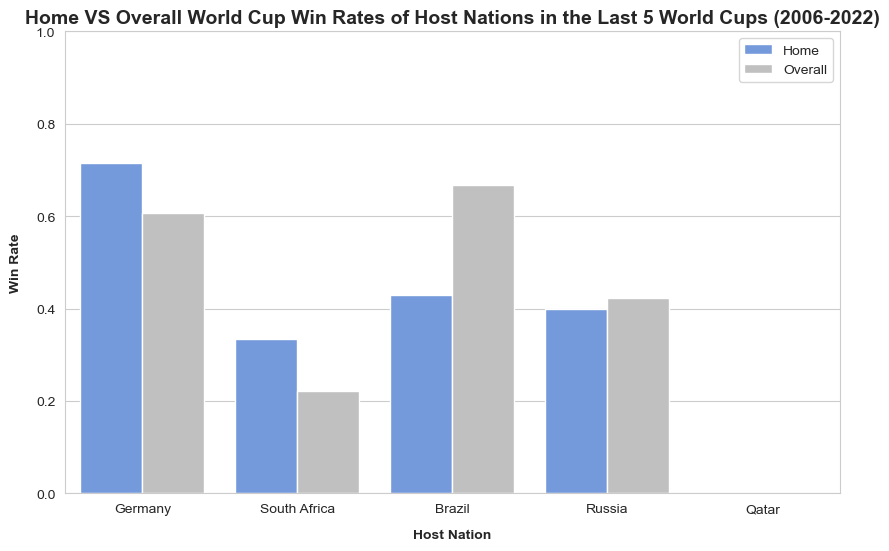

In [181]:
# Filter for World Cup matches
wcresults = results[results["tournament"] == "FIFA World Cup"]
wcresults["year"] = wcresults["date"].dt.year # creating a year column

# Filter for the last 5 World Cups (2006, 2010, 2014, 2018, 2022)
last5_wcresults = wcresults[wcresults["year"] >= 2006]

hosts = {
    2006: "Germany",
    2010: "South Africa",
    2014: "Brazil",
    2018: "Russia",
    2022: "Qatar"
}

# Function to calculate win rate for a given team in a given dataframe of matches
def calculate_win_rate(df, team):
    
    # Matches where team played
    matches = df[
        (df["home_team"] == team) | (df["away_team"] == team)
    ]
    
    total_matches = len(matches)
    
    # Count wins
    wins = (
        ((matches["home_team"] == team) & (matches["home_score"] > matches["away_score"])) |
        ((matches["away_team"] == team) & (matches["away_score"] > matches["home_score"]))
    ).sum()
    
    # Avoid division by zero
    if total_matches == 0:
        return 0
    
    return wins / total_matches

# Calculate win rates for host nations in their respective World Cups
host_wc_winrates = []

for year, host in hosts.items():
    # Matches from that specific World Cup
    tournament_matches = last5_wcresults[
        last5_wcresults["year"] == year
    ]
    
    host_winrate = calculate_win_rate(
        tournament_matches,
        host
    )
    
    host_wc_winrates.append({
        "year": year,
        "host": host,
        "host_wc_winrate": host_winrate
    })

# Calculating overall win rates for the host nations across all their World Cup matches 
for row in host_wc_winrates:
    host = row["host"]
    
    overall_winrate = calculate_win_rate(
        wcresults,
        host
    )
    
    row["overall_wc_winrate"] = overall_winrate

host_winrates_df = pd.DataFrame(host_wc_winrates)

# Plot
plot_df = host_winrates_df.melt(
    id_vars=["year", "host"],
    value_vars=[
        "host_wc_winrate",
        "overall_wc_winrate"
    ],
    var_name="context",
    value_name="win_rate"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.barplot(
        data=plot_df,
        x="host",
        y="win_rate",
        hue="context",
        ax=ax,
        palette=["cornflowerblue", "silver"]
    )

plt.title("Home VS Overall World Cup Win Rates of Host Nations in the Last 5 World Cups (2006-2022)", fontsize=14, fontweight="bold")

handles, _ = ax.get_legend_handles_labels() # Legend handles for custom legend labels
plt.legend(
    handles,
    ["Home", "Overall"],
    title=""
)
plt.ylabel("Win Rate", labelpad=10, fontweight="bold")
plt.xlabel("Host Nation", labelpad=10, fontweight="bold")
plt.ylim(0,1)
plt.show()

### Historical World Cup Performance of World Cup 2026 Hosts (Canada, Mexico, USA)

A line chart showing the win rate over time of Canada, Mexico and the USA in the World Cups they participated in.

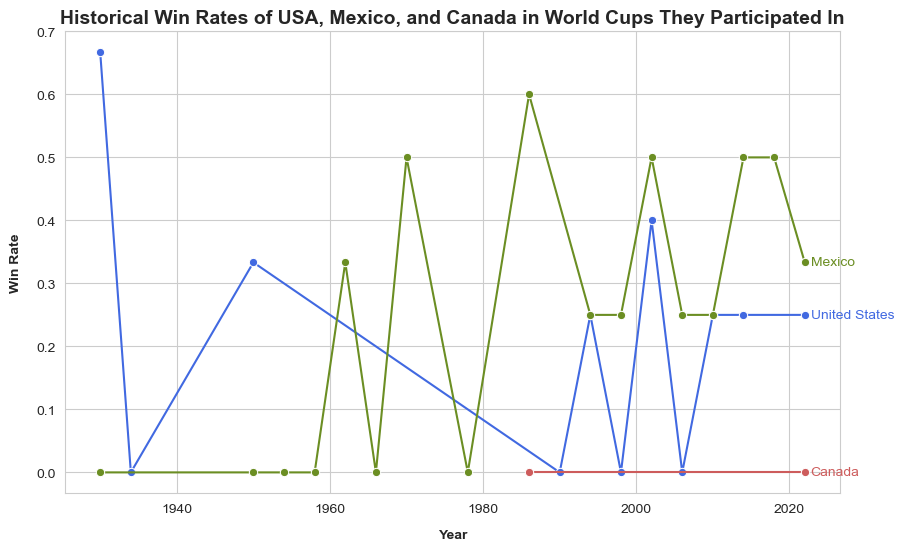

In [182]:
# List of World Cup years
wc_years = wcresults["year"].unique().tolist()

# Creating lists to store win rates for Canada, Mexico, and USA for each World Cup year they participated in
canada_winrates = []
mexico_winrates = []
usa_winrates = []

# Calculate win rates
for year in wc_years:
    res = wcresults[wcresults["year"] == year]
    if "Canada" in res["home_team"].values or "Canada" in res["away_team"].values: # only calculate win rate if they participated in that World Cup
        canada_winrate = calculate_win_rate(res, "Canada")
        canada_winrates.append({"year": year, "win_rate": canada_winrate})
    if "Mexico" in res["home_team"].values or "Mexico" in res["away_team"].values:
        mexico_winrate = calculate_win_rate(res, "Mexico")
        mexico_winrates.append({"year": year, "win_rate": mexico_winrate})
    if "United States" in res["home_team"].values or "United States" in res["away_team"].values:
        usa_winrate = calculate_win_rate(res, "United States")
        usa_winrates.append({"year": year, "win_rate": usa_winrate})

# Convert lists to DataFrames for plotting
canada_winrates_df = pd.DataFrame(canada_winrates)
mexico_winrates_df = pd.DataFrame(mexico_winrates)
usa_winrates_df = pd.DataFrame(usa_winrates)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

lines = [
    (usa_winrates_df, "United States", "royalblue"),
    (mexico_winrates_df, "Mexico", "olivedrab"),
    (canada_winrates_df, "Canada", "indianred")
]

for df, label, color in lines:
    sns.lineplot(df, x="year", y="win_rate", marker="o", color=color, ax=ax, legend=False)
    # Get the last point of each line and place label there
    last_row = df.iloc[-1]
    ax.text(last_row["year"] + 0.77, last_row["win_rate"], label, color=color, va="center", fontsize=10)

plt.title("Historical Win Rates of USA, Mexico, and Canada in World Cups They Participated In", fontsize=14, fontweight="bold")
plt.xlabel("Year", labelpad=10, fontweight="bold")
plt.ylabel("Win Rate", labelpad=10, fontweight="bold")
plt.show()

- Canada has participated in two world cups and has never won a single match.
- Mexico and USA display inconsistency across each iteration of the world cup they participated in.

### Most Common Tournaments

In [183]:
with pd.option_context('display.max_seq_items', None):
    print(results["tournament"].unique())

<StringArray>
[                                     'Friendly',
                     'British Home Championship',
                          'Évence Coppée Trophy',
                                  'Muratti Vase',
                                   'Copa Lipton',
                                   'Copa Newton',
                   'Copa Premio Honor Argentino',
                                 'Olympic Games',
                    'Copa Premio Honor Uruguayo',
                'Far Eastern Championship Games',
                                     'Copa Roca',
                                  'Copa América',
                            'Inter-Allied Games',
                                     'Peace Cup',
               'Open International Championship',
                                  'Soccer Ashes',
                       'Copa Chevallier Boutell',
                           'Nordic Championship',
            'Central European International Cup',
                                    

Bar chart of the top 7 most common tournaments based on the total number of matches played.

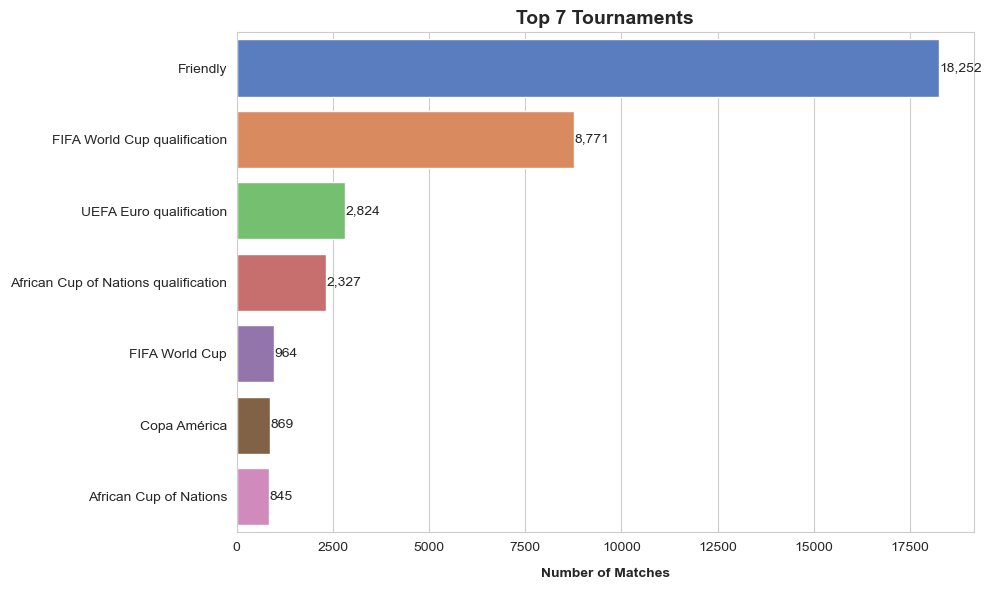

In [184]:
top7_tournaments = (
    results["tournament"]
    .value_counts(ascending=False)
    .head(7)
    .reset_index()
)
top7_tournaments.columns = ["tournament", "count"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top7_tournaments,
    x="count",
    y="tournament",
    palette="muted",
    ax=ax,
    hue="tournament",
    legend=False
)

# Add data labels
for bar in ax.patches:
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va="center", ha="left", fontsize=10
    )

ax.set_title("Top 7 Tournaments", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Matches", labelpad=10, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Friendlies make up a large proportion of the dataset, followed by the World Cup qualifiers.

## FIFA 26 Player Ratings
### Availability of Player Ratings per Country

A bar chart of the number of players in each country participating in the World Cup 2026 with FIFA 26 ratings.

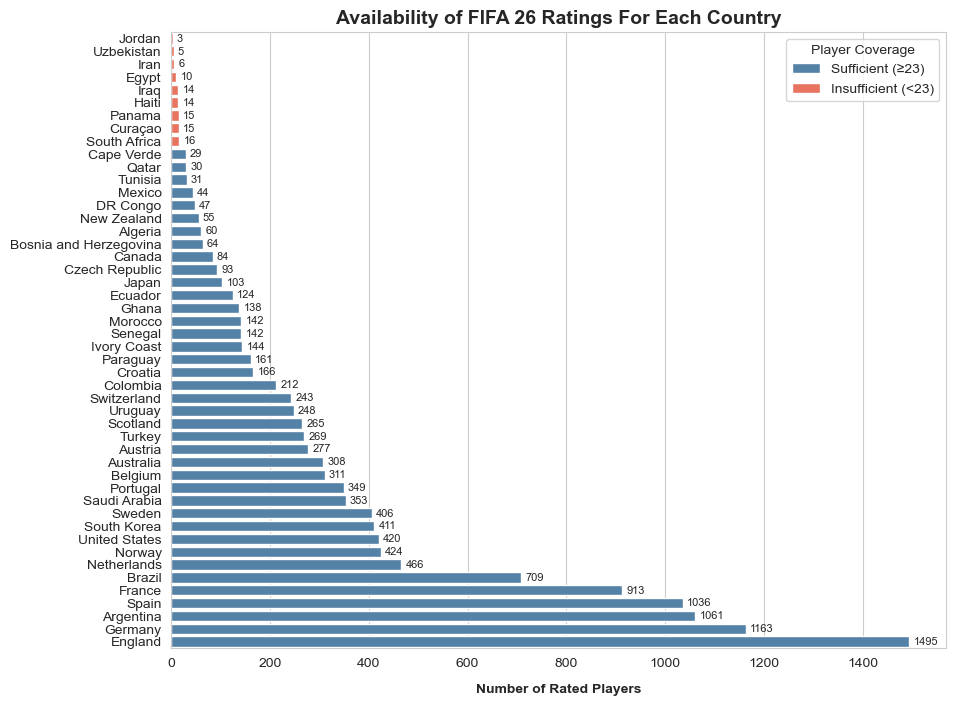

In [185]:
# Data preparation
player_counts = (
    wcplayers
    .groupby("nationality")
    .size()
    .reset_index(name="count")
)

countries = wc2026_draw[["country"]].copy()

coverage = countries.merge( # joining the list of countries with the player counts
    player_counts,
    left_on="country",
    right_on="nationality",
    how="left"
)

coverage["count"] = coverage["count"].fillna(0).astype(int) # dealing with Qatar which has no players in the players dataset

coverage = coverage.sort_values(by="count", ascending=True).reset_index(drop=True)
coverage["low_count"] = coverage["count"] < 23 # distinguishing countries with fewer than 23 rated players

# Plot
plt.figure(figsize=(10,8))
ax = sns.barplot(
    data=coverage,
    x="count",
    y="country",
    hue="low_count",
    palette={
        True: "tomato",
        False: "steelblue"
    }
)
# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=8
    )
plt.title(
    "Availability of FIFA 26 Ratings For Each Country",
    fontsize=14,
    fontweight="bold"
)
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Sufficient (≥23)", "Insufficient (<23)"], title="Player Coverage")
plt.xlabel("Number of Rated Players", labelpad=10, fontweight="bold")
plt.ylabel("")
plt.show()

- 9 countries (in red) do not have at least 23 players (the minimum size of a World Cup squad) with player ratings.
- There is the most information on English players.

The availability of FIFA ratings for players in each country is also a possible indication of squad strength. EA Sports primarily rates players who have established themselves in well-known professional leagues, meaning countries with fewer rated players likely have weaker squads overall. 

### Distribution of Player Ratings

Histogram of the overall ratings of players from countries participating in the 2026 World Cup.

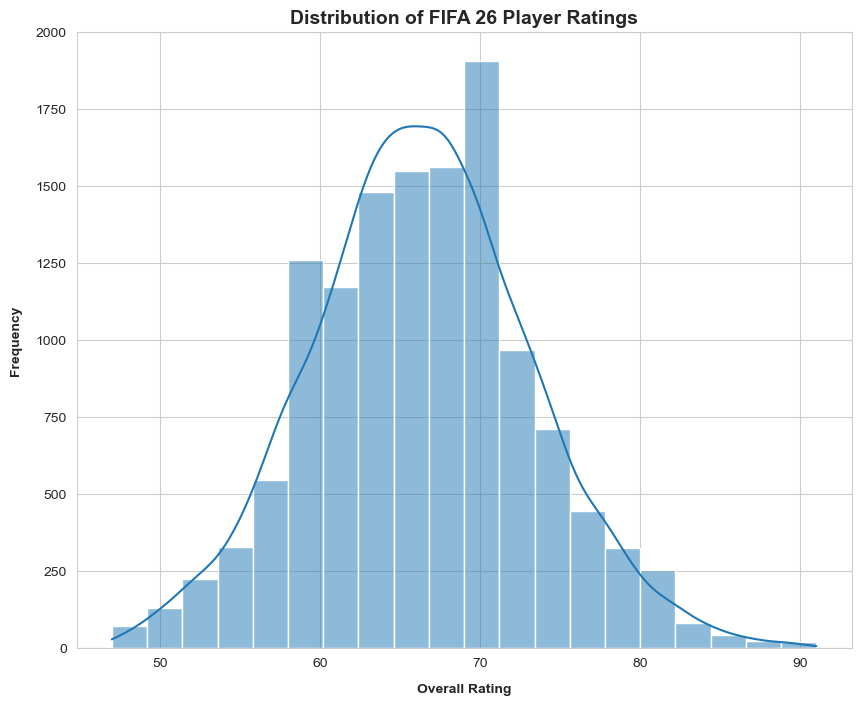

In [195]:
plt.figure(figsize=(10,8))

sns.histplot(
    wcplayers["overall"],
    bins=20,
    kde=True
)

plt.title("Distribution of FIFA 26 Player Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Overall Rating", labelpad=10, fontweight="bold")
plt.ylabel("Frequency", labelpad=10, fontweight="bold")
plt.show()

## Distribution of Latest Elo Ratings 

### Across Confederations

Box plots of elo ratings according to confederations.

/Users/edenaong/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


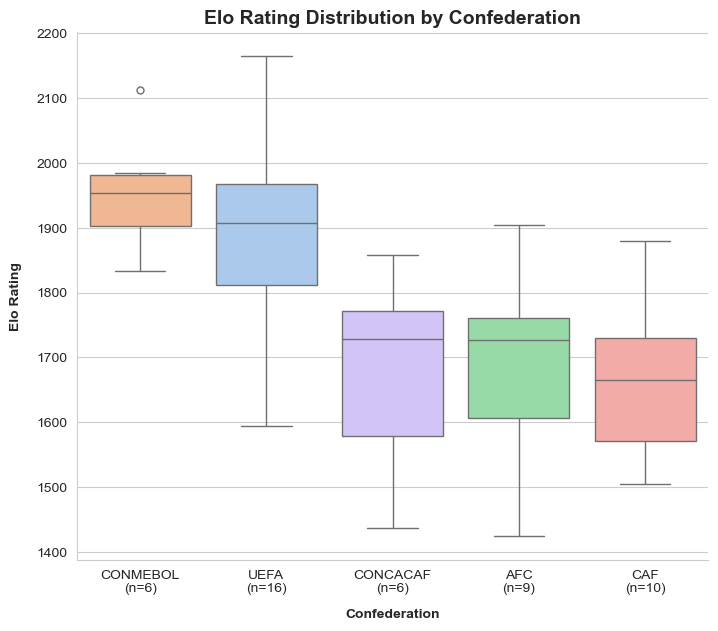

In [187]:
# Exclude OFC 
wc2026_elo_no_ofc = wc2026_elo[wc2026_elo["confederation"] != "OFC"]

conf_order = (
    wc2026_elo_no_ofc.groupby("confederation")["total_points"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

counts = wc2026_elo_no_ofc["confederation"].value_counts().loc[conf_order].tolist() # get counts in the same order as confederations

# Plot
ax = sns.catplot(
        data=wc2026_elo_no_ofc,
        x="confederation",
        y="total_points",
        kind="box",
        palette="pastel",
        hue="confederation",
        legend=False,
        order=conf_order,
        height=6,
        aspect=1.2
    )

plt.title("Elo Rating Distribution by Confederation", fontsize=14, fontweight="bold")
plt.xlabel("Confederation", labelpad=10, fontweight="bold")
plt.ylabel("Elo Rating", labelpad=10, fontweight="bold")
ax.set_xticklabels([f"{conf}\n(n={count})" for conf, count in zip(conf_order, counts)]) # add sample sizes to x labels
plt.show()

- As expected, CONMEBOL and UEFA countries have the highest median Elo ratings. 
- UEFA demonstrates the greatest variance due to a greater number of representing countries. 
- CONMEBOL outperforms UEFA, with the outlier being the defending champions Argentina. 

### Across Groups

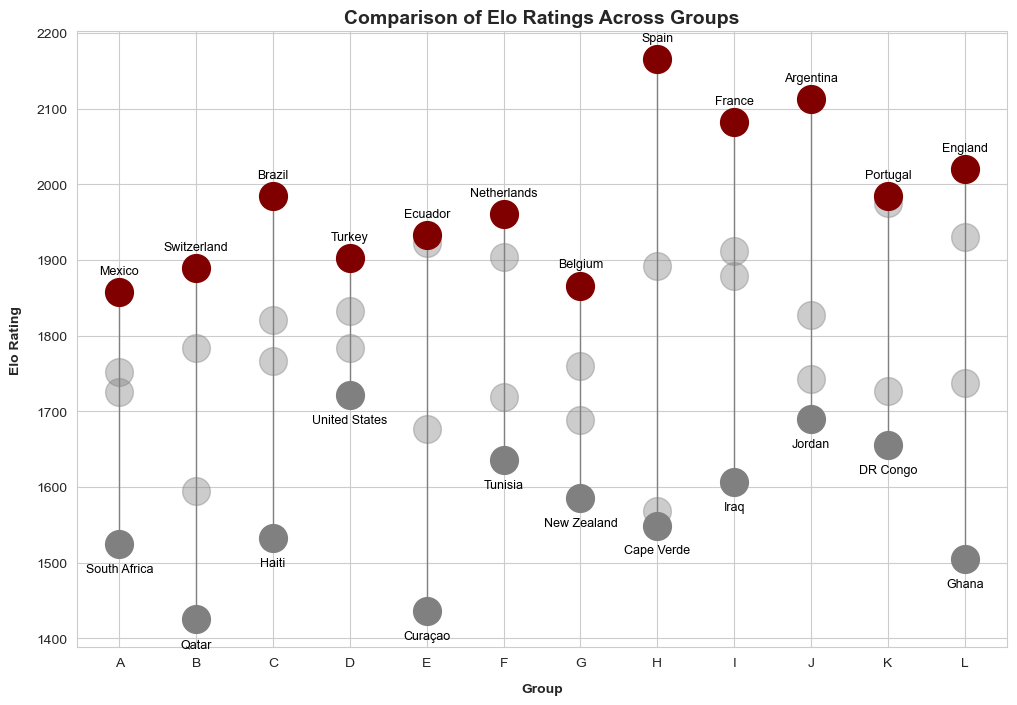

In [188]:
# Joining the elo ratings with the World Cup draw to get the group information for each country in the elo ratings dataset
elo_with_group = wc2026_elo.merge(wc2026_draw, left_on = "country_full", right_on = "country", how = "left")

# List of groups in the World Cup draw
groups = wc2026_draw["group"].unique().tolist()

# Plot 
fig, ax = plt.subplots(figsize=(12, 8))
plt.ylabel("Elo Rating", labelpad=10, fontweight="bold")
plt.xlabel("Group", labelpad=10, fontweight="bold")
plt.title("Comparison of Elo Ratings Across Groups", fontsize=14, fontweight="bold")

for group in groups:
    group_df = elo_with_group[elo_with_group["group"] == group]
    group_df = group_df[["country_full", "total_points", "group"]].sort_values(by="total_points", ascending=False)

    ax.scatter(group, group_df["total_points"].iloc[0], color="maroon", s=400, zorder=2) # highest rated team in the group
    ax.scatter(group, group_df["total_points"].iloc[-1], color="gray", s=400, zorder=2) # lowest rated team in the group
    ax.scatter(group, group_df["total_points"].iloc[1], color="gray", alpha=0.4, s=400, zorder=1) # remaining two teams in the group
    ax.scatter(group, group_df["total_points"].iloc[2], color="gray", alpha=0.4, s=400, zorder=1)
    ax.plot((group, group), (group_df["total_points"].iloc[0], group_df["total_points"].iloc[-1]), color="gray", linewidth=1, zorder=1) # line connecting the highest and lowest rated teams in the group
    ax.text(group, group_df["total_points"].iloc[0]+20, group_df["country_full"].iloc[0], color="black", ha="center", va="bottom", fontsize=9) # label for highest rated team
    ax.text(group, group_df["total_points"].iloc[-1]-25, group_df["country_full"].iloc[-1], color="black", ha="center", va="top", fontsize=9) # label for lowest rated team

plt.show()

The more difficult groups are groups where the top two or more teams are close in performance. According to the latest elo ratings, groups D, E, F and K are likely to be more competitive as the elo ratings of at least the top two teams are similar.